In [1]:
# Load the data
load("AAD.RData", verbose = TRUE)

Loading objects:
  AAD


In [2]:
# Summary of Data
summary(AAD)

  Patient.ID        Antibiotic.class   D1.Shannon.diversity
 Length:335         Length:335         Min.   :0.1276      
 Class :character   Class :character   1st Qu.:2.8984      
 Mode  :character   Mode  :character   Median :3.3923      
                                       Mean   :3.2493      
                                       3rd Qu.:3.7653      
                                       Max.   :4.4653      
 D6.Shannon.diversity D1.Chao1.diversity D6.Chao1.diversity
 Min.   :0.07041      Min.   : 25.14     Min.   : 36.15    
 1st Qu.:2.52770      1st Qu.:138.46     1st Qu.:118.18    
 Median :3.07407      Median :189.96     Median :169.00    
 Mean   :2.86372      Mean   :200.84     Mean   :174.42    
 3rd Qu.:3.48406      3rd Qu.:247.91     3rd Qu.:222.03    
 Max.   :4.46100      Max.   :552.93     Max.   :422.75    
 D1.D6.Jaccard.distance   Outcome         
 Min.   :0.2448         Length:335        
 1st Qu.:0.5352         Class :character  
 Median :0.6598         Mode  :

In [3]:
# Individual item calculations (Example for D1 Shannon)
mean(AAD$D1.Shannon.diversity, na.rm = TRUE)
median(AAD$D1.Shannon.diversity, na.rm = TRUE)
min(AAD$D1.Shannon.diversity, na.rm = TRUE)
max(AAD$D1.Shannon.diversity, na.rm = TRUE)
quantile(AAD$D1.Shannon.diversity, na.rm = TRUE, c(0.25, 0.75))

[1] 3.249321

[1] 3.392265

[1] 0.127635

[1] 4.465318

25%      75% 
2.898378 3.765255

In [4]:
# Frequency table calculation for categorical data
table(AAD$Antibiotic.class)
table(AAD$Outcome)


FQN OBL PBL 
 56 111 168 


AAD CDI  ND 
 22   5 308 

In [5]:
# Calculate the correlation coefficient using Pearson
cor_1 <- cor(AAD$D1.Shannon.diversity, AAD$D6.Shannon.diversity, use = "complete.obs")
cor_1

[1] 0.2208003

In [6]:
cor_2 <- cor(AAD$D1.Chao1.diversity, AAD$D6.Chao1.diversity, use = "complete.obs")
cor_2

[1] 0.3026013

In [7]:
# Calculate the correlation coefficient using Spearman
cor(AAD$D1.Shannon.diversity, AAD$D6.Shannon.diversity, use = "complete.obs", method = "spearman")
cor(AAD$D1.Chao1.diversity, AAD$D6.Chao1.diversity, use = "complete.obs", method = "spearman")

[1] 0.2293046

[1] 0.3315932

In [9]:
install.packages("corrplot")
# Visualizing Correlations
library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



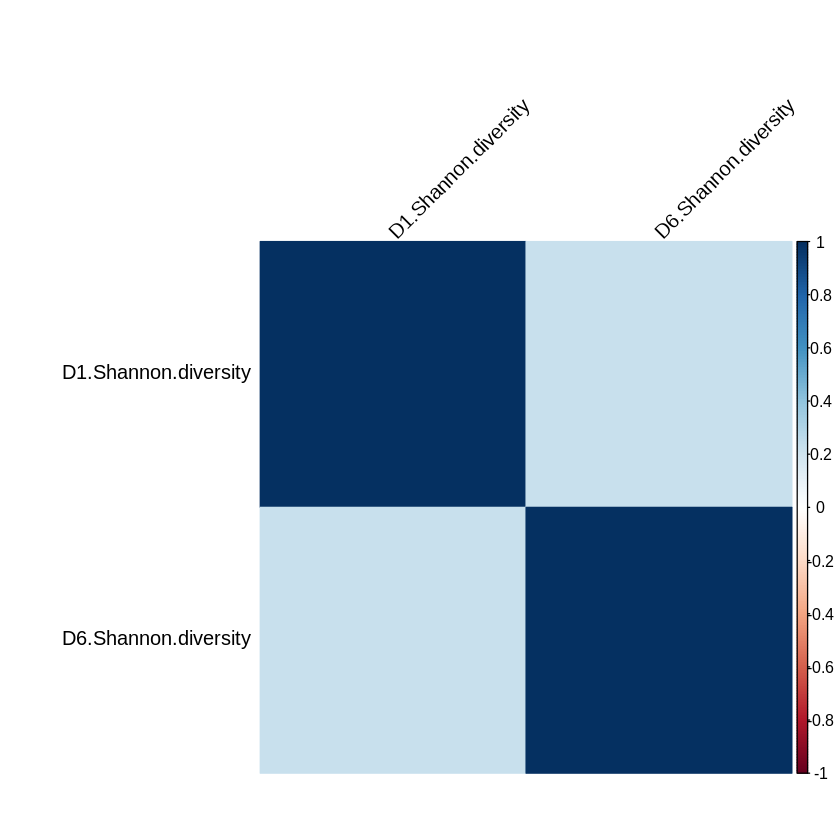

In [10]:
cormat_shannon <- cor(AAD[, c("D1.Shannon.diversity", "D6.Shannon.diversity")], use = "complete.obs")
corrplot(cormat_shannon, method = "color", tl.col = "black", tl.srt = 45)

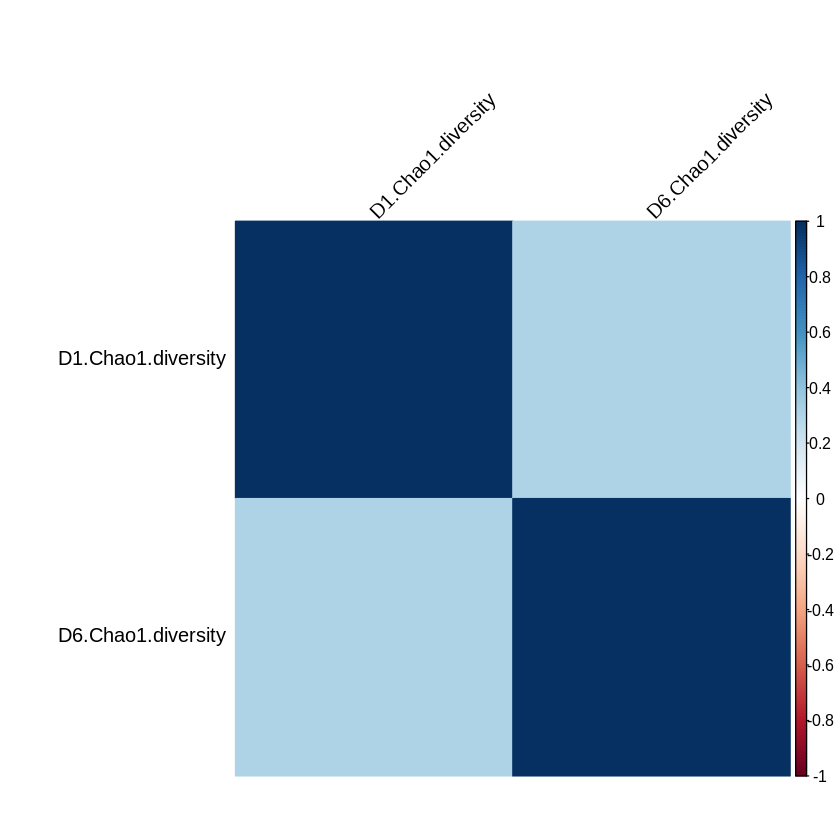

In [11]:
cormat_chao <- cor(AAD[, c("D1.Chao1.diversity", "D6.Chao1.diversity")], use = "complete.obs")
corrplot(cormat_chao, method = "color", tl.col = "black", tl.srt = 45)

In [12]:
library(ggplot2)

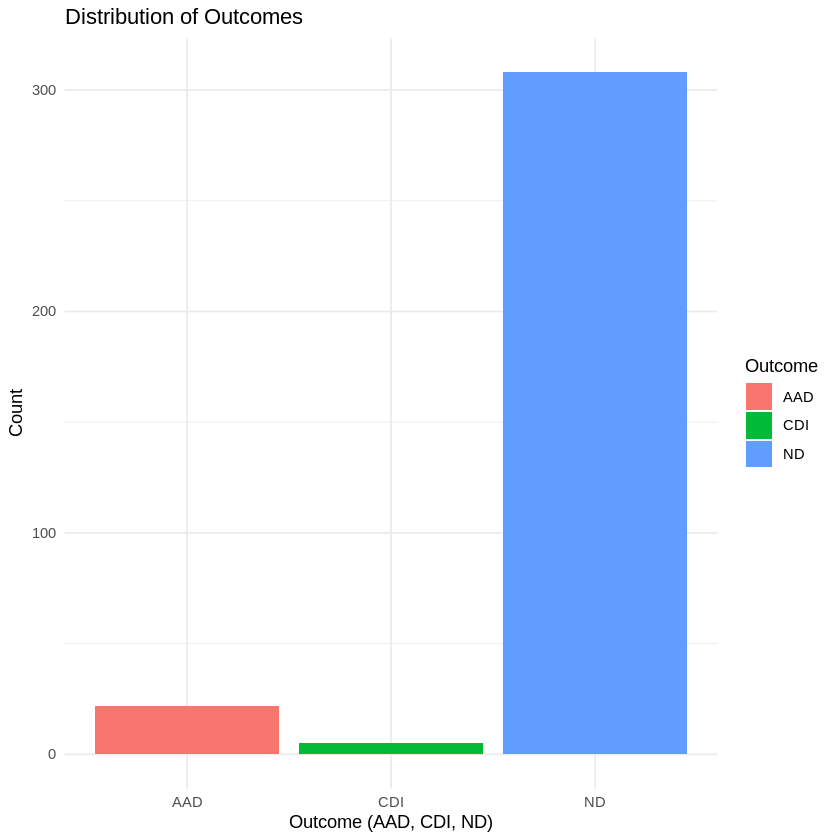

In [14]:
# 2.1 Bar chart of Outcomes
ggplot(AAD, aes(x = Outcome, fill = Outcome)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Distribution of Outcomes", x = "Outcome (AAD, CDI, ND)", y = "Count")

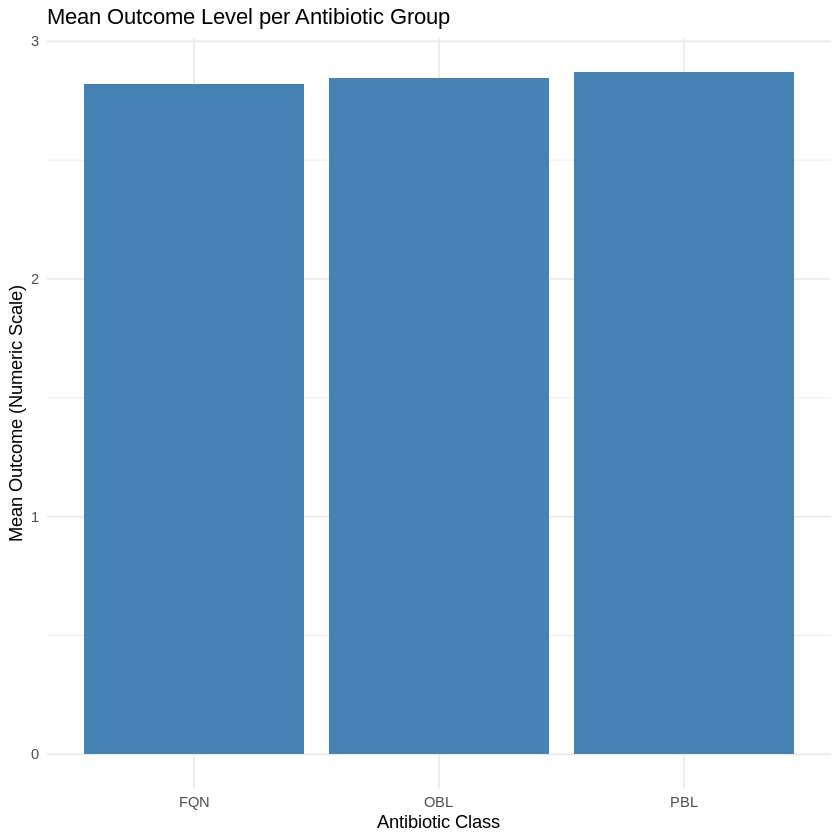

In [16]:
# 2.2 Bar chart: Mean Outcome per Antibiotic Group
ggplot(AAD, aes(x = Antibiotic.class, y = as.numeric(as.factor(Outcome)))) +
  stat_summary(fun = mean, geom = "bar", fill = "steelblue") +
  theme_minimal() +
  labs(title = "Mean Outcome Level per Antibiotic Group", y = "Mean Outcome (Numeric Scale)", x = "Antibiotic Class")

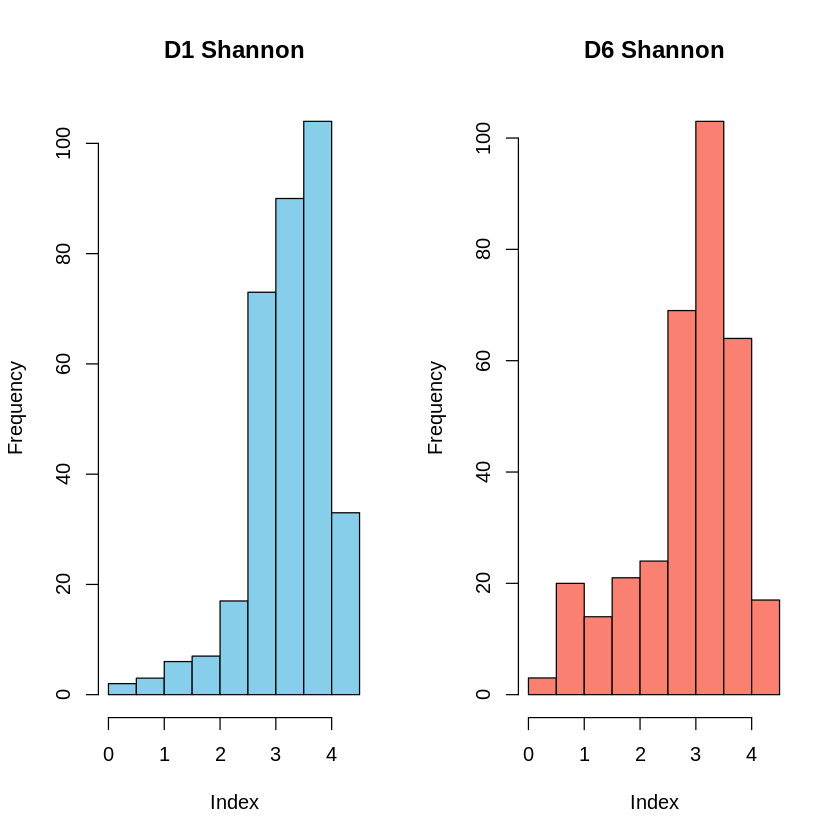

In [18]:
# 2.3 Histograms for Shannon Diversity
par(mfrow=c(1,2))
hist(AAD$D1.Shannon.diversity, col="skyblue", main="D1 Shannon", xlab="Index")
hist(AAD$D6.Shannon.diversity, col="salmon", main="D6 Shannon", xlab="Index")
par(mfrow=c(1,1))

`geom_smooth()` using formula = 'y ~ x'


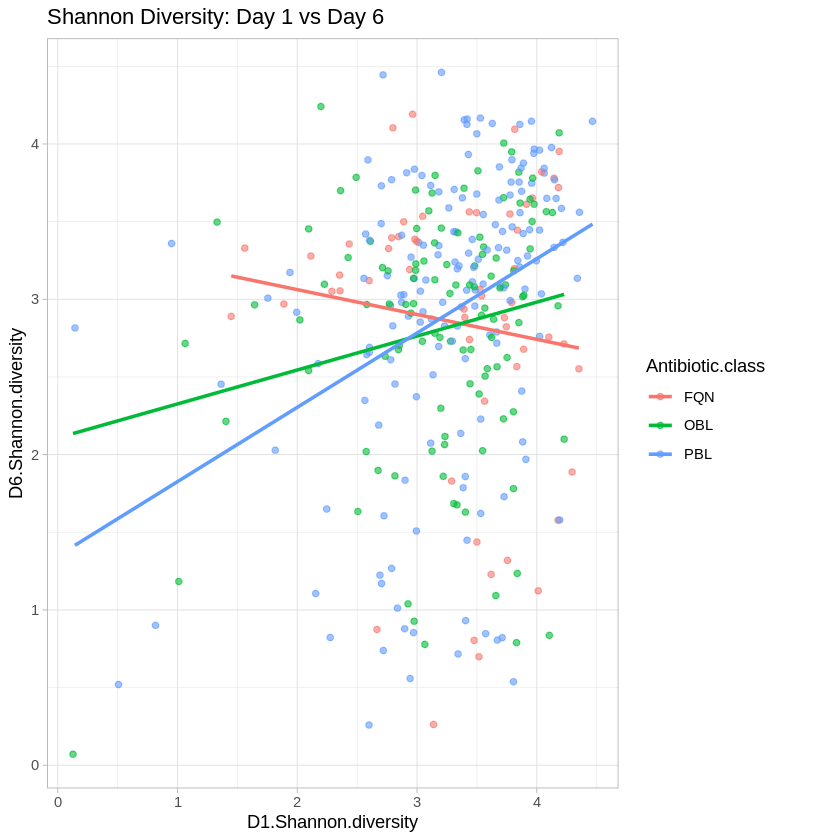

In [20]:
# 2.4 Scatterplot: Shannon D1 vs D6 with regression lines
ggplot(AAD, aes(x = D1.Shannon.diversity, y = D6.Shannon.diversity, color = Antibiotic.class)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = FALSE) +
  theme_light() +
  labs(title = "Shannon Diversity: Day 1 vs Day 6")

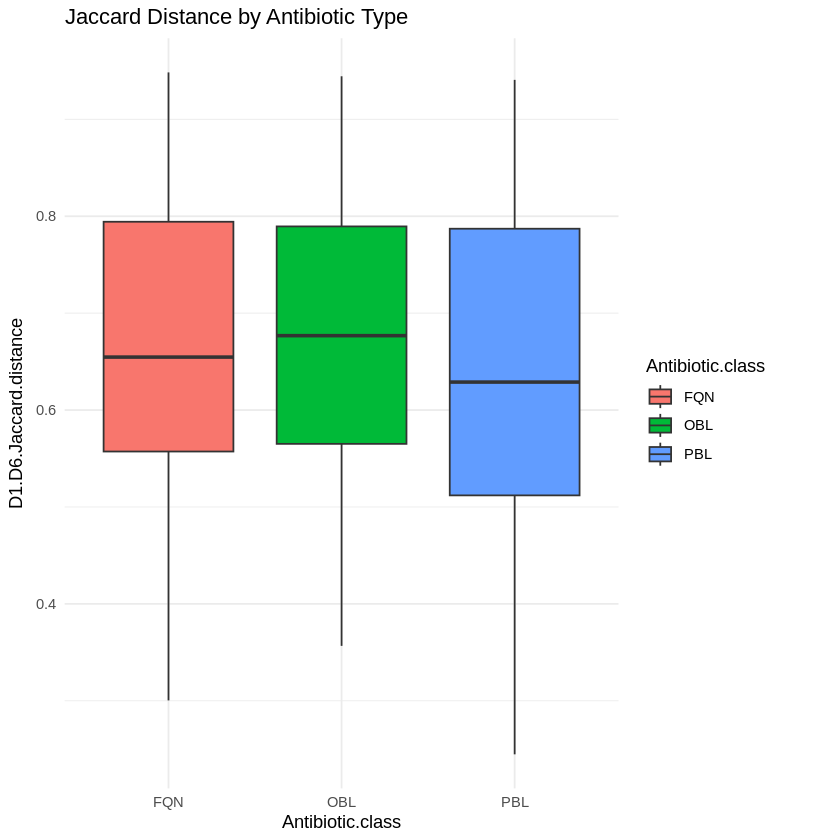

In [22]:
# 2.5 Boxplots of Jaccard Distance
ggplot(AAD, aes(x = Antibiotic.class, y = D1.D6.Jaccard.distance, fill = Antibiotic.class)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Jaccard Distance by Antibiotic Type")

In [25]:
out_vals <- boxplot.stats(AAD$D1.D6.Jaccard.distance)$out
print("Outliers identified:")
print(out_vals)

[1] "Outliers identified:"
numeric(0)


In [28]:
# View the full rows for these outliers
AAD[AAD$D1.D6.Jaccard.distance %in% out_vals, ]

Patient.ID,Antibiotic.class,D1.Shannon.diversity,D6.Shannon.diversity,D1.Chao1.diversity,D6.Chao1.diversity,D1.D6.Jaccard.distance,Outcome
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>



	Shapiro-Wilk normality test

data:  AAD$D6.Shannon.diversity
W = 0.91549, p-value = 8.795e-13


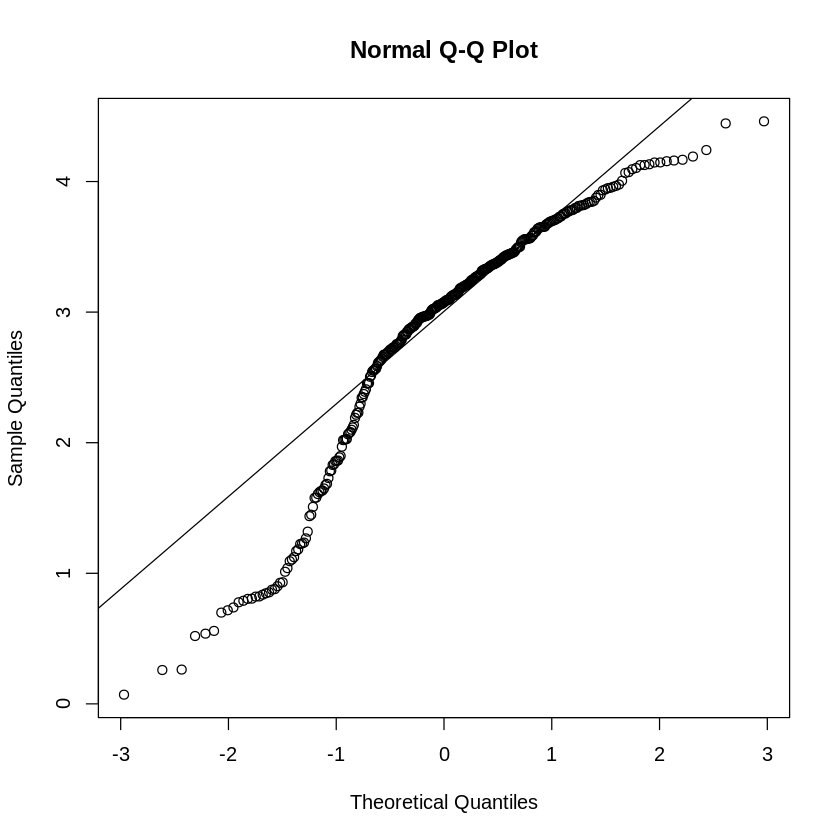

In [30]:
# Normality Check (D6 Shannon)
shapiro.test(AAD$D6.Shannon.diversity)
qqnorm(AAD$D6.Shannon.diversity); qqline(AAD$D6.Shannon.diversity)


	Bartlett test of homogeneity of variances

data:  D1.D6.Jaccard.distance by Antibiotic.class
Bartlett's K-squared = 3.865, df = 2, p-value = 0.1448


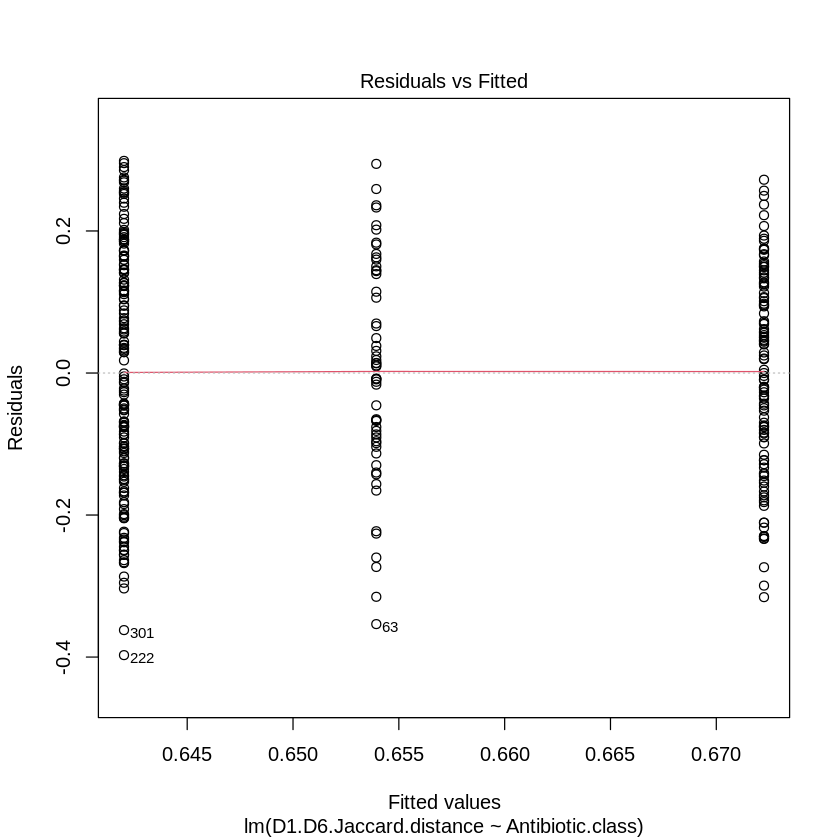

In [32]:
# Homoscedasticity Check (Jaccard Distance vs Antibiotics)
bartlett.test(D1.D6.Jaccard.distance ~ Antibiotic.class, data = AAD)
plot(lm(D1.D6.Jaccard.distance ~ Antibiotic.class, data = AAD), which = 1)

In [33]:
### V. STATISTICAL INFERENCE ###

# Subset Jaccard distance per Antibiotic group
PBL <- AAD[AAD$Antibiotic.class=="PBL",]$D1.D6.Jaccard.distance
OBL <- AAD[AAD$Antibiotic.class=="OBL",]$D1.D6.Jaccard.distance
FQN <- AAD[AAD$Antibiotic.class=="FQN",]$D1.D6.Jaccard.distance

In [34]:
# Function to compute mean, SE, and multiple CIs
summary_stats <- function(x, conf.levels = c(0.90, 0.95, 0.99)) {
  n <- length(x)
  mean_x <- mean(x, na.rm = TRUE)
  se_x <- sd(x, na.rm = TRUE) / sqrt(n)

  CI_df <- do.call(rbind, lapply(conf.levels, function(cl) {
    alpha <- 1 - cl
    t_crit <- qt(1 - alpha / 2, df = n - 1)
    ci_lower <- mean_x - t_crit * se_x
    ci_upper <- mean_x + t_crit * se_x
    data.frame(conf.level = paste0(cl*100, "%"), lower = ci_lower, upper = ci_upper)
  }))
  return(list(mean = mean_x, SE = se_x, n = n, CIs = CI_df))
}

In [35]:
# View Results
summary_stats(PBL)

conf.level,lower,upper
<chr>,<dbl>,<dbl>
90%,0.6207265,0.6633013
95%,0.6166050,0.6674228
99%,0.6084799,0.6755479


In [36]:
summary_stats(OBL)

conf.level,lower,upper
<chr>,<dbl>,<dbl>
90%,0.6501390,0.6943684
95%,0.6458337,0.6986737
99%,0.6373082,0.7071992


In [37]:
summary_stats(FQN)

conf.level,lower,upper
<chr>,<dbl>,<dbl>
90%,0.6198198,0.6880488
95%,0.6130703,0.6947983
99%,0.5995273,0.7083413


In [39]:
# 6.1 Shannon Day 6: CDI vs ND (T-test)
t.test(D6.Shannon.diversity ~ Outcome, data = subset(AAD, Outcome %in% c("CDI", "ND")), var.equal = TRUE)


	Two Sample t-test

data:  D6.Shannon.diversity by Outcome
t = 0.3636, df = 311, p-value = 0.7164
alternative hypothesis: true difference in means between group CDI and group ND is not equal to 0
95 percent confidence interval:
 -0.6437360  0.9355816
sample estimates:
mean in group CDI  mean in group ND 
         3.049826          2.903903 


In [40]:
# 6.2 Jaccard: OBL vs FQN (Welch T-test for heteroscedasticity)
t.test(D1.D6.Jaccard.distance ~ Antibiotic.class, data = subset(AAD, Antibiotic.class %in% c("OBL", "FQN")), var.equal = FALSE)


	Welch Two Sample t-test

data:  D1.D6.Jaccard.distance by Antibiotic.class
t = -0.75196, df = 102.69, p-value = 0.4538
alternative hypothesis: true difference in means between group FQN and group OBL is not equal to 0
95 percent confidence interval:
 -0.06663772  0.02999888
sample estimates:
mean in group FQN mean in group OBL 
        0.6539343         0.6722537 


In [41]:
# 6.3 Jaccard across all Antibiotics (ANOVA + Post-hoc)
fit_anova <- aov(D1.D6.Jaccard.distance ~ Antibiotic.class, data = AAD)

In [42]:
summary(fit_anova)

                  Df Sum Sq Mean Sq F value Pr(>F)
Antibiotic.class   2  0.061 0.03056   1.253  0.287
Residuals        332  8.098 0.02439               

In [43]:
TukeyHSD(fit_anova)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = D1.D6.Jaccard.distance ~ Antibiotic.class, data = AAD)

$Antibiotic.class
               diff         lwr        upr     p adj
OBL-FQN  0.01831942 -0.04194691 0.07858574 0.7544150
PBL-FQN -0.01192043 -0.06865495 0.04481408 0.8739116
PBL-OBL -0.03023985 -0.07521348 0.01473378 0.2544052


In [44]:
# Fit linear model for Jaccard Distance
lm_model <- lm(D1.D6.Jaccard.distance ~ Antibiotic.class, data = AAD)

In [45]:
summary(lm_model)


Call:
lm(formula = D1.D6.Jaccard.distance ~ Antibiotic.class, data = AAD)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.39726 -0.11969 -0.00488  0.13238  0.29873 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)          0.65393    0.02087  31.334   <2e-16 ***
Antibiotic.classOBL  0.01832    0.02560   0.716    0.475    
Antibiotic.classPBL -0.01192    0.02410  -0.495    0.621    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1562 on 332 degrees of freedom
Multiple R-squared:  0.007491,	Adjusted R-squared:  0.001512 
F-statistic: 1.253 on 2 and 332 DF,  p-value: 0.287


In [46]:
# 95% Confidence Interval for the slope
confint(lm_model, level = 0.95)

,2.5 %,97.5 %
(Intercept),0.61288033,0.69498828
Antibiotic.classOBL,-0.03203667,0.06867550
Antibiotic.classPBL,-0.05932548,0.03548461
